In [51]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dataclasses import dataclass
from typing import Annotated, List
from langchain_core.messages import AnyMessage

from dotenv import load_dotenv
import os

from langchain_groq import ChatGroq
from IPython.display import display, Image

from langgraph.prebuilt import ToolNode, tools_condition

In [52]:
@dataclass
class MyBotwithToolBinding:
    messages: Annotated[List[AnyMessage], add_messages]

In [53]:
def add(a: float, b:float) -> float:
    """ 
    Function is Created to Perform Addition of two Numbers
    :param a: First Argument to Perform Addition Operatio
    :type a: float

    :param b: Second Argument to Perform Addition Operation
    :type b: float

    :returns: Sum of Two Inputs
    :rtype: float

    .. code-block :: python
        #Example

        >>> add(3,5)
        8.0

        >>> add(2.1,5.2)
        7.3
    """

    return a+b

In [54]:
import os
load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [55]:
llm = ChatGroq(model = 'openai/gpt-oss-120b')
llm_tool = llm.bind_tools([add])
print(llm_tool.invoke("What is ML").content)
print('----------------------------------------')
print(llm_tool.invoke("What is 2 plus 3"))

**Machine Learning (ML)** is a subfield of artificial intelligence (AI) that focuses on building systems that can learn from data, improve their performance over time, and make decisions or predictions without being explicitly programmed for each specific task.

### Core Ideas
| Concept | What it means |
|---------|---------------|
| **Data‑driven** | Algorithms discover patterns in historical data. |
| **Model** | A mathematical representation (e.g., a neural network, decision tree) that maps inputs to outputs. |
| **Training** | The process of adjusting a model’s parameters using data so it can make accurate predictions. |
| **Inference/Prediction** | Using the trained model to produce outputs on new, unseen data. |
| **Generalization** | The ability of a model to perform well on data it hasn’t seen before. |

### Main Types of ML
| Type | Description | Typical Algorithms |
|------|-------------|--------------------|
| **Supervised Learning** | Learns from labeled examples (input‑out

In [56]:
def llmToolAgent(state: MyBotwithToolBinding):

    print("------- You are Dealing with Tool Agent")
    return {"messages" :[llm_tool.invoke(state.messages)]}

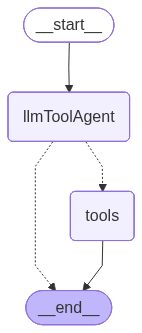

In [57]:
graph = StateGraph(MyBotwithToolBinding)

graph.add_node("llmToolAgent",llmToolAgent)
graph.add_node("tools", ToolNode([add]))

graph.add_edge(START, "llmToolAgent")
graph.add_conditional_edges("llmToolAgent",tools_condition)

graph.add_edge("tools", END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [61]:
result = graph_builder.invoke(MyBotwithToolBinding(messages="What is 2 plus 3"))

for item in result['messages']:
    print(item.model_dump_json())

------- You are Dealing with Tool Agent
{"content":"What is 2 plus 3","additional_kwargs":{},"response_metadata":{},"type":"human","name":null,"id":"257c8584-7ca1-4dcf-bb95-5adb55af8225"}
{"content":"","additional_kwargs":{"reasoning_content":"User asks: \"What is 2 plus 3\". Simple addition. Could just answer 5. Could also use function add. Use function.","tool_calls":[{"id":"fc_6bac5272-911e-427b-92ed-124296b2d686","function":{"arguments":"{\"a\":2,\"b\":3}","name":"add"},"type":"function"}]},"response_metadata":{"token_usage":{"completion_tokens":64,"prompt_tokens":223,"total_tokens":287,"completion_time":0.135490221,"completion_tokens_details":{"reasoning_tokens":31},"prompt_time":0.008519415,"prompt_tokens_details":null,"queue_time":0.033547018,"total_time":0.144009636},"model_name":"openai/gpt-oss-120b","system_fingerprint":"fp_7ff1dfc284","service_tier":"on_demand","finish_reason":"tool_calls","logprobs":null,"model_provider":"groq"},"type":"ai","name":null,"id":"lc_run--2db575c

In [64]:
result = graph_builder.invoke(MyBotwithToolBinding(messages="What is LLM"))

for item in result['messages']:
    print(item.model_dump_json())

------- You are Dealing with Tool Agent
{"content":"What is LLM","additional_kwargs":{},"response_metadata":{},"type":"human","name":null,"id":"67135259-a3a8-4116-a1cd-61d5acd5d87c"}
{"content":"**LLM = Large Language Model**\n\nA *large language model* (LLM) is a type of artificial‑intelligence system that learns to generate and understand human language by training on massive amounts of text data. Here’s a quick breakdown of what makes an LLM distinct:\n\n| Aspect | Explanation |\n|--------|--------------|\n| **Scale** | “Large” refers to both the size of the training dataset (often billions of words) and the number of parameters (the adjustable weights inside the model). Modern LLMs have anywhere from hundreds of millions to hundreds of billions of parameters. |\n| **Architecture** | Most LLMs are built on the **Transformer** architecture, introduced in the 2017 paper *“Attention Is All You Need.”* This design excels at capturing long‑range dependencies in text through self‑attentio